In [29]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from imblearn.under_sampling import RandomUnderSampler
from python_scripts.preprocessing import *
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import warnings
warnings.simplefilter(action='ignore')

Loading dataset : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [30]:
# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\ejeme\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


In [31]:
df = pd.read_csv('C:/Users/ejeme/Documents/breast-cancer.csv')
df['diagnosis'].replace({'M':1, 'B':0}, inplace=True)
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [32]:
print(df.shape)
print('Proportion of 1s:', np.round(df.diagnosis.sum()/df.shape[0],2))

(569, 31)
Proportion of 1s: 0.37


In [33]:
balance = None
df = generate_imbalanced_datasets(df, [balance], label_col='diagnosis')[0].sample(frac=1, random_state=0)

In [34]:
print(df.shape)
print('Proportion of 1s:', np.round(df.diagnosis.sum()/df.shape[0],2))

(569, 31)
Proportion of 1s: 0.37


#### some preprocessing

In [35]:
X = df.drop(['diagnosis'], axis=1).sample(2, axis=1, random_state=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# If you want a DataFrame back
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Y = df.diagnosis

In [36]:
X

,perimeter_mean,symmetry_worst
512,83.74,0.3549
457,70.92,0.2998
439,76.20,0.2220
298,88.59,0.3065
37,123.40,0.2841
...,...,...
277,83.18,0.3297
9,66.20,0.2434
359,66.82,0.2699
192,87.50,0.4378


In [37]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.5, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [38]:
model = LogisticRegression(random_state=0, max_iter=100)
model.fit(X_train, Y_train)

LogisticRegression(random_state=0)

In [39]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       179
           1       0.91      0.89      0.90       106

    accuracy                           0.93       285
   macro avg       0.92      0.92      0.92       285
weighted avg       0.93      0.93      0.93       285

Test Accuracy: 0.9263157894736842


### Retrieving $\kappa_f$ confidence function

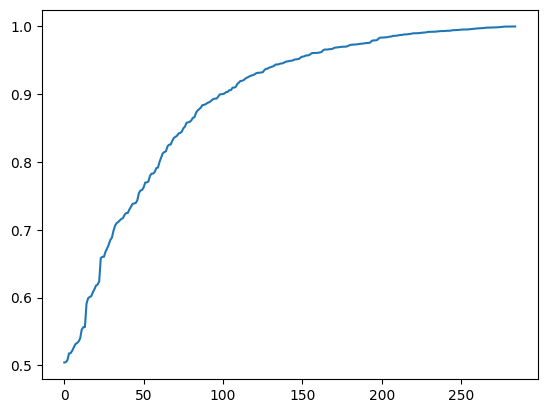

In [40]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [41]:
sgr_df = pd.DataFrame({'y_true': y_true,
                       'y_pred': y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
70,0,0,0.504393
108,1,1,0.504854
157,1,0,0.507942
450,1,0,0.517829
10,0,1,0.518053
...,...,...,...
196,1,1,0.999881
463,1,1,0.999947
81,1,1,0.999990
484,1,1,0.999992


In [42]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))